# 智能体


## 单智能体(single-agent)的局限
- 长上下文局限
- 工具过多,注意力丢失

## 多智能体(multi-agent)
注意: 需要搞定智能体之间的消息传递


情况一: 智能体之间有相同或者部分相同的状态


情况二:智能体之间没有相同的状态

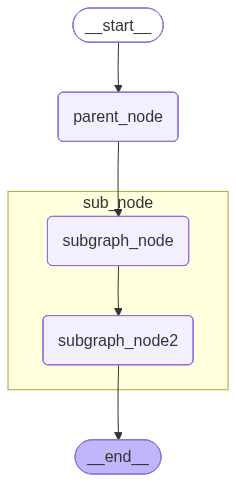

{'user_input': '我现在想要学习大模型,应该关注哪些技术?'}
{'user_input': '我现在想要学习大模型,应该关注哪些技术?', 'final_answer': AIMessage(content='# 大模型学习路线图\n\n学习大模型是一个系统工程，我按照**基础→核心→进阶→应用**的顺序来梳理：\n\n---\n\n## 一、必备基础\n\n| 领域 | 关键知识点 |\n|------|-----------|\n| **数学** | 线性代数、概率统计、微积分、信息论基础 |\n| **编程** | Python 熟练、PyTorch/TensorFlow |\n| **机器学习基础** | 损失函数、优化器、正则化、评估指标 |\n| **深度学习基础** | CNN、RNN/LSTM、Embedding |\n\n---\n\n## 二、核心架构（重点！）\n\n### 1. Transformer 架构\n- **自注意力机制**（Self-Attention）\n- 多头注意力（Multi-Head Attention）\n- 位置编码（Positional Encoding）\n- Layer Normalization\n- 残差连接\n\n### 2. 主流架构变体\n- **Encoder-only**：BERT（理解任务）\n- **Decoder-only**：GPT 系列（生成任务，当前主流）\n- **Encoder-Decoder**：T5（序列到序列）\n\n---\n\n## 三、预训练技术\n\n| 技术 | 说明 |\n|------|------|\n| **语言建模** | Causal LM、Masked LM |\n| **数据工程** | 数据清洗、去重、质量过滤、数据配比 |\n| **分布式训练** | 数据并行、张量并行、流水线并行、ZeRO |\n| **训练稳定性** | 学习率调度、梯度裁剪、混合精度训练 |\n\n---\n\n## 四、微调与对齐技术（热门）\n\n### 1. 参数高效微调（PEFT）\n- **LoRA / QLoRA** ⭐（最常用）\n- Adapter Tuning\n- Prefix Tuning\n- Prompt Tuning\n\n##

In [ ]:
# 情况二: 智能体之间有相同或者部分相同的状态

from typing import TypedDict
import os
import dotenv
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt

from config import config
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

llm = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    temperature=os.getenv("TEMPERATURE"),
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    openai_api_base=os.getenv("OPENAI_BASE_URL"),
)


# 定义父图的状态
class ParentState(TypedDict):
    user_input: str
    final_answer: str


def parent_node(state: ParentState):
    response = llm.invoke(state["user_input"])
    return {"final_answer": response}


# 定义子图的状态
class SubgraphState(TypedDict):
    summary_answer: str
    final_answer: str


def subgraph_node(state: SubgraphState):
    system_prompt = """ 
      请描述你的内容.字数不多于50字
    """

    messages = state["final_answer"]
    messages = [SystemMessage(content=system_prompt)] + [
        HumanMessage(content=messages.content)
    ]
    response = llm.invoke(messages)
    return {"summary_answer": response}


def subgraph_node2(state: SubgraphState):
    messages = f""" 
    完整回答:{state["final_answer"]}\n
    概要回答:{state["summary_answer"]}\n
    请给这个概要打分:1-10分
    """
    response = llm.invoke([HumanMessage(content=messages)])
    return {"final_answer": response.content}


subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node)
subgraph_builder.add_node(subgraph_node2)
subgraph_builder.add_edge(START, "subgraph_node")
subgraph_builder.add_edge("subgraph_node", "subgraph_node2")
subgraph = subgraph_builder.compile()

builder = StateGraph(ParentState)
builder.add_node("parent_node", parent_node)
builder.add_node("sub_node", subgraph)
builder.add_edge(START, "parent_node")
builder.add_edge("parent_node", "sub_node")
graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

async for chunk in graph.astream({"user_input": "我现在想要学习大模型,应该关注哪些技术?"},stream_mode="values",subgraphs=True):
    print(chunk)

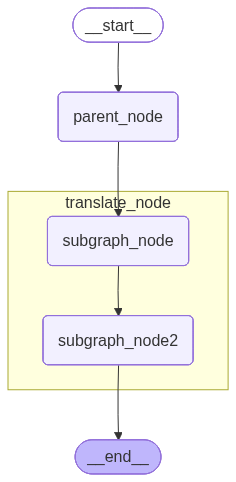

((), {'user_input': '我现在想要学习大模型,应该关注哪些技术?'})
((), {'user_input': '我现在想要学习大模型,应该关注哪些技术?', 'final_answer': AIMessage(content='# 🚀 学习大模型（LLM）的技术路线图\n\n学习大模型是一个系统性工程，我建议你按照以下层次逐步深入：\n\n---\n\n## 一、基础功底（必备）\n\n### 1. 数学基础\n- **线性代数**：矩阵运算、特征值分解（理解注意力机制的基础）\n- **概率统计**：贝叶斯、概率分布（理解语言模型的生成过程）\n- **微积分**：梯度下降、链式求导（理解反向传播）\n\n### 2. 编程能力\n- **Python**：必须熟练\n- **深度学习框架**：**PyTorch**（主流）、TensorFlow\n- **Linux + Git** 基本操作\n\n---\n\n## 二、深度学习核心（必经之路）\n\n\n\n| 技术主题 | 重点内容 |\n|---------|---------|\n| 神经网络基础 | CNN、RNN、LSTM 的原理 |\n| **Transformer** | ⭐ 最核心！自注意力机制、Multi-Head Attention、位置编码 |\n| 预训练语言模型 | BERT（理解）、GPT系列（生成） |\n| 优化技术 | Adam、学习率调度、梯度裁剪 |\n\n> 💡 **Transformer 是重中之重**，可以说"不懂 Transformer，就不懂大模型"。\n\n---\n\n## 三、大模型核心技术\n\n\n\n### 1. 预训练（Pre-training）\n- 大规模语料处理与清洗\n- 自回归（GPT）vs 自编码（BERT）vs Encoder-Decoder（T5）\n- 分布式训练：数据并行、模型并行、流水线并行\n- **DeepSpeed、Megatron-LM、FSDP** 等训练框架\n\n### 2. 微调与对齐（Fine-tuning & Alignment）\n- **SFT**（监督微调）\n- **RLHF**（基于人类反馈的强化学习）：PPO 算法\n- **DPO**（直接偏好优化）—— 更新更简洁的方案\

In [5]:
# 情况二: 智能体之间有不同的状态

from typing import TypedDict
import os
import dotenv
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt

from config import config
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

llm = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    temperature=os.getenv("TEMPERATURE"),
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    openai_api_base=os.getenv("OPENAI_BASE_URL"),
)


# 定义父图的状态
class ParentState(TypedDict):
    user_input: str
    final_answer: str


def parent_node(state: ParentState):
    response = llm.invoke(state["user_input"])
    return {"final_answer": response}


# 定义子图的状态
class SubgraphState(TypedDict):
    summary_answer: str
    response_answer: str
    score: str


def subgraph_node(state: SubgraphState):
    system_prompt = """ 
      请描述你的内容.字数不多于50字
    """

    messages = state["response_answer"]
    messages = [SystemMessage(content=system_prompt)] + [
        HumanMessage(content=messages.content)
    ]
    response = llm.invoke(messages)
    return {"summary_answer": response}


def subgraph_node2(state: SubgraphState):
    messages = f""" 
    完整回答:{state["response_answer"]}\n
    概要回答:{state["summary_answer"]}\n
    请给这个概要打分:1-10分
    """
    response = llm.invoke([HumanMessage(content=messages)])
    return {"score": response.content}


subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node)
subgraph_builder.add_node(subgraph_node2)
subgraph_builder.add_edge(START, "subgraph_node")
subgraph_builder.add_edge("subgraph_node", "subgraph_node2")
subgraph = subgraph_builder.compile()


def translate_node(state: ParentState):
    # 1. 父图状态 → 子图输入：手动转换 key
    response = subgraph.invoke({"response_answer": state["final_answer"]})
    # 2. 子图输出 → 父图状态：手动提取 key
    return {"final_answer": response["score"]}


builder = StateGraph(ParentState)
builder.add_node("parent_node", parent_node)
builder.add_node("translate_node", translate_node)
builder.add_edge(START, "parent_node")
builder.add_edge("parent_node", "translate_node")
graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


async for chunk in graph.astream(
    {"user_input": "我现在想要学习大模型,应该关注哪些技术?"},
    stream_mode="values",
    subgraphs=True,
):
    print(chunk)

多agent架构
- 基于network
- supervisor
  - magentic-one



graphRAG
知识图谱(图数据库)
传统rag(向量数据库)